## Steps Include : - 
- Import Required Libraries
- Load the Dataset
- Dataset Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Selection
- Data Preprocessing
- Model Building
- Model Evaluation
- Model Comparison
- Conclusion

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

df = pd.read_csv("dataset.csv")

In [2]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9549, 23)


In [4]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

In [6]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [7]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.dtypes

Age                      float64
BMI                      float64
Blood_Pressure           float64
Cholesterol              float64
Glucose_Level            float64
Heart_Rate               float64
Sleep_Hours              float64
Exercise_Hours           float64
Water_Intake             float64
Stress_Level             float64
Target                     int64
Smoking                    int64
Alcohol                    int64
Diet                       int64
MentalHealth               int64
PhysicalActivity           int64
MedicalHistory             int64
Allergies                  int64
Diet_Type__Vegan            bool
Diet_Type__Vegetarian       bool
Blood_Group_AB              bool
Blood_Group_B               bool
Blood_Group_O               bool
dtype: object

In [10]:
df.nunique()

Age                      101
BMI                       14
Blood_Pressure           175
Cholesterol               16
Glucose_Level             15
Heart_Rate                14
Sleep_Hours               15
Exercise_Hours             9
Water_Intake              11
Stress_Level              13
Target                     2
Smoking                    3
Alcohol                    3
Diet                       3
MentalHealth               3
PhysicalActivity           3
MedicalHistory             3
Allergies                  3
Diet_Type__Vegan           2
Diet_Type__Vegetarian      2
Blood_Group_AB             2
Blood_Group_B              2
Blood_Group_O              2
dtype: int64

## ----- Data Exploration ---------

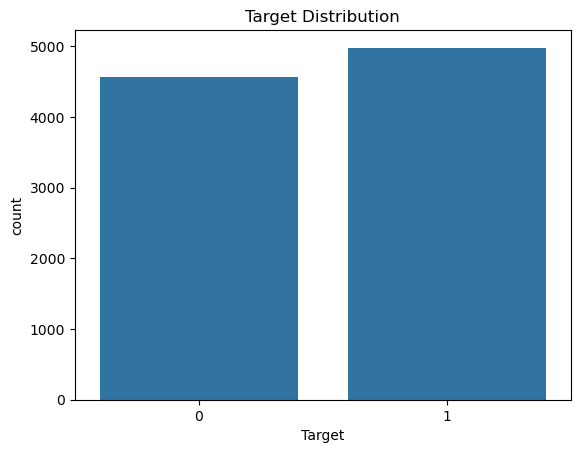

In [11]:
# Target Class Distribution

sns.countplot(x='Target', data=df)
plt.title("Target Distribution")
plt.show()

## Observation

- Dataset is nearly balanced.
- No severe class imbalance.

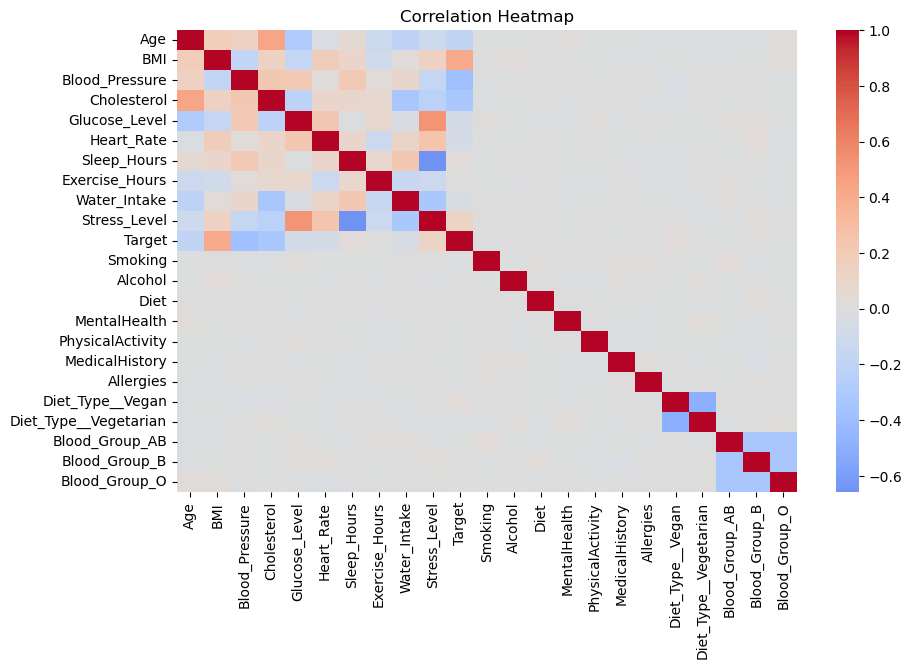

In [12]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

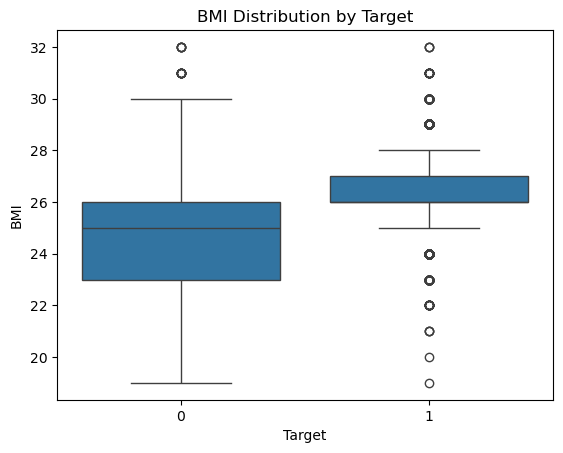

In [13]:
# BMI vs Target

sns.boxplot(x='Target', y='BMI', data=df)
plt.title("BMI Distribution by Target")
plt.show()

## Observation

- Positive cases generally have higher BMI.
- BMI looks like one of the most informative predictors.

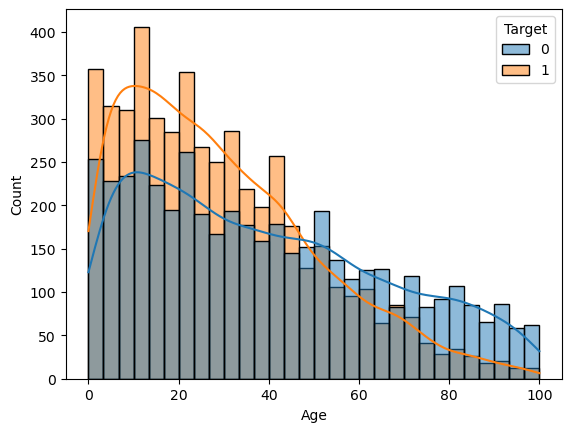

In [14]:
# Age Distribution - Target

sns.histplot(data=df,
             x='Age',
             hue='Target',
             bins=30,
             kde=True)
plt.show()

## Observation

- Age distributions differ between the two target classes.
- Younger individuals tend to appear more frequently in the positive class.

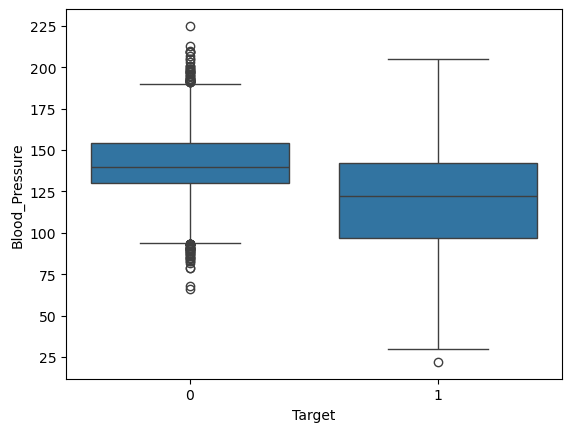

In [15]:
# Blood Pressure vs Target

sns.boxplot(x='Target',
            y='Blood_Pressure',
            data=df)
plt.show()

# Observation

- Blood pressure varies noticeably between target classes. It has one of the strongest negative correlations with the target.

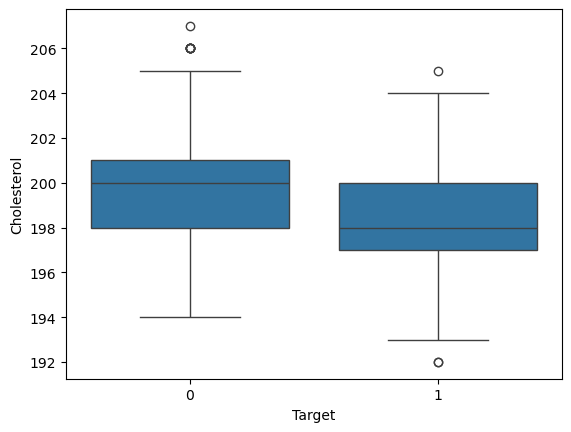

In [16]:
# Cholesterol vs Target 

sns.boxplot(x='Target',
            y='Cholesterol',
            data=df)
plt.show()

## Observation

- Cholesterol differs between classes.
- Useful feature for prediction.

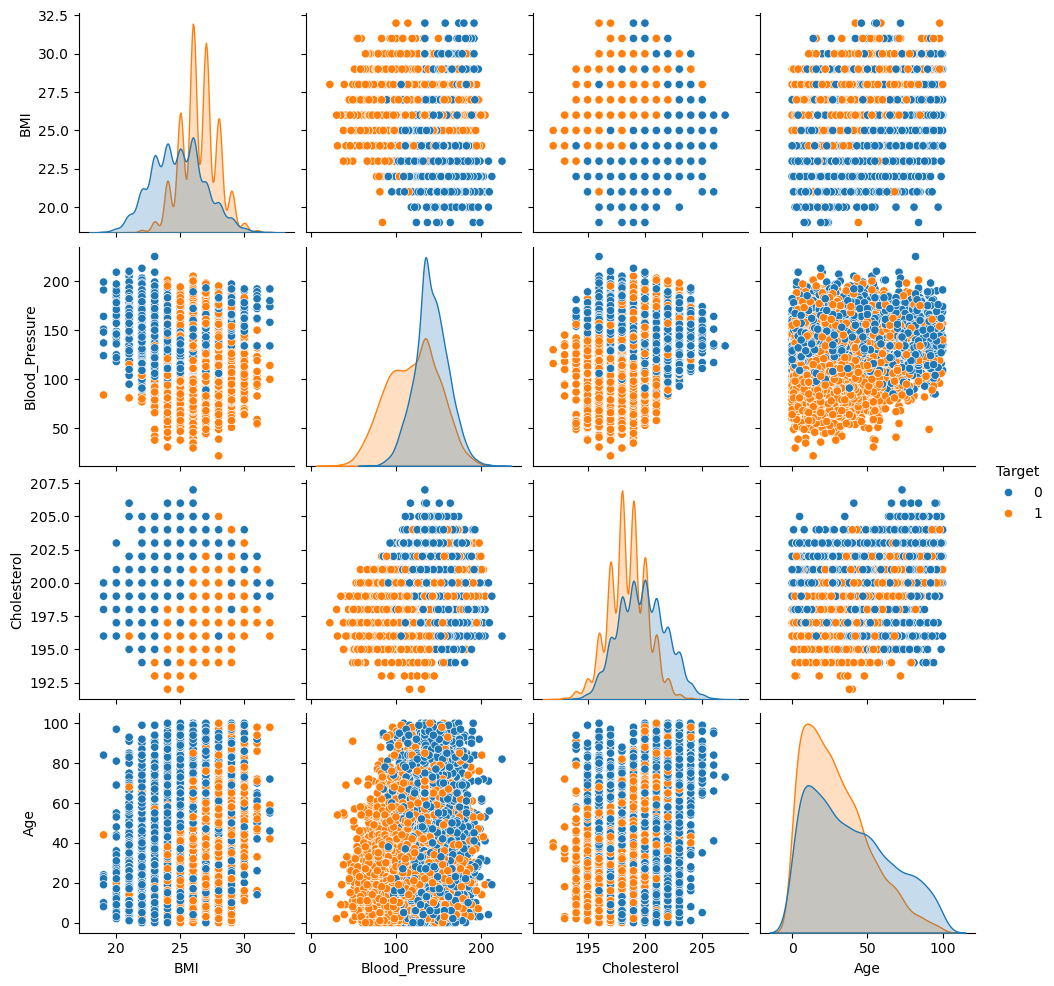

In [17]:
# Pairplot of Top Features
cols = ['BMI',
        'Blood_Pressure',
        'Cholesterol',
        'Age',
        'Target']

sns.pairplot(df[cols], hue='Target')
plt.show()

The pairplot visualizes the relationships among BMI, Blood Pressure, Cholesterol, and Age while distinguishing the two target classes. BMI exhibits the clearest separation between classes, indicating it is a strong predictor of the target variable. Blood Pressure and Age also show noticeable differences, whereas Cholesterol demonstrates moderate overlap. Overall, although no single feature completely separates the classes, combining these features provides useful information for building an accurate classification model.

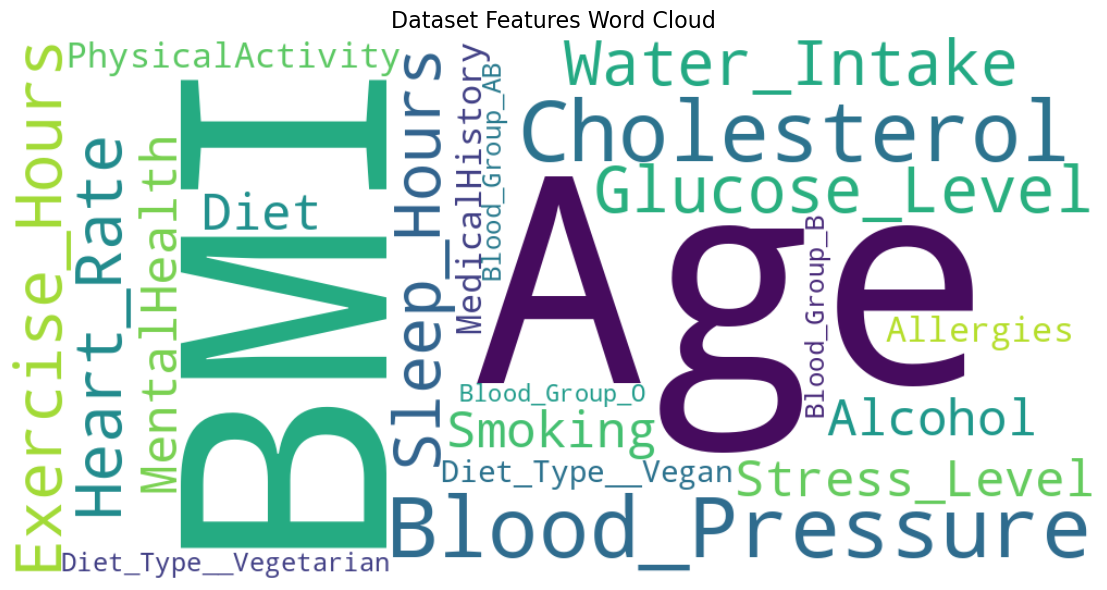

In [18]:
# Wordcloud to Represent all features name

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Feature names (excluding the target column)
text = " ".join(df.drop(columns=['Target']).columns)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Dataset Features Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()

# *MODEL TRAINING*

In [19]:
# Split features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# model -1 Logistic Regression (with Regulaization)
log_reg = LogisticRegression(
    solver="liblinear",
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

# In Model Evaluation, Recall is more important than accuracy 
# because missing a high-risk patient is dangerous

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8141361256544503
Logistic Regression Recall: 0.8283132530120482
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



In [21]:
## Model 2 - KNN
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8832460732984293
KNN Recall: 0.8835341365461847
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       914
           1       0.89      0.88      0.89       996

    accuracy                           0.88      1910
   macro avg       0.88      0.88      0.88      1910
weighted avg       0.88      0.88      0.88      1910



In [22]:
# Random Forest Model
# Hyper Parameter tunning 
#Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall",   
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Recall:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

best_rf.fit(X_train_scaled, y_train)

y_pred_best = best_rf.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_best))

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Recall: 0.9480280953071507
Accuracy : 0.9387434554973823
Precision: 0.9238187078109933
Recall   : 0.9618473895582329
F1 Score : 0.9424495818986719

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       914
           1       0.92      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



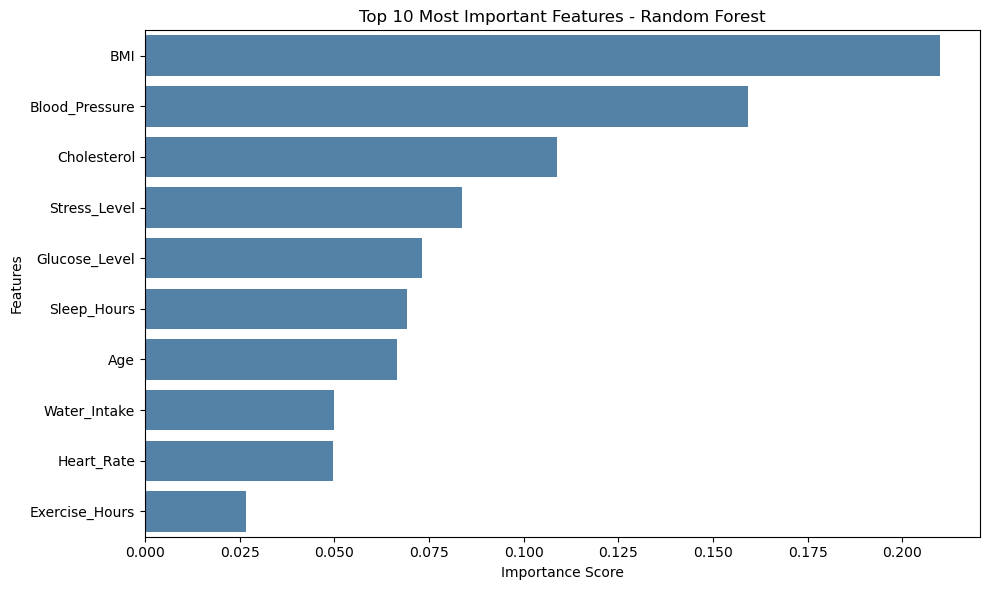

In [24]:
# Feature importance 
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 10 Most Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

- The Random Forest model identifies the most influential features contributing to patient risk prediction. The top-ranked features have the greatest impact on the model's decision-making process, indicating that they play a significant role in distinguishing between low-risk and high-risk patients. These insights improve model interpretability and can help healthcare professionals understand which patient characteristics should receive greater attention during risk assessment.

In [25]:
# Gradient Boosting (Ensemble Learning)
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9303664921465968
Gradient Boosting Recall: 0.9497991967871486
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910



In [26]:
# Voting Classifier (Ensemble Learning)
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, solver="liblinear")),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
    ],
    voting="soft"
)

voting_clf.fit(X_train_scaled, y_train)

y_pred_vote = voting_clf.predict(X_test_scaled)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Voting Classifier Recall:", recall_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))


Voting Classifier Accuracy: 0.9157068062827225
Voting Classifier Recall: 0.929718875502008
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       914
           1       0.91      0.93      0.92       996

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



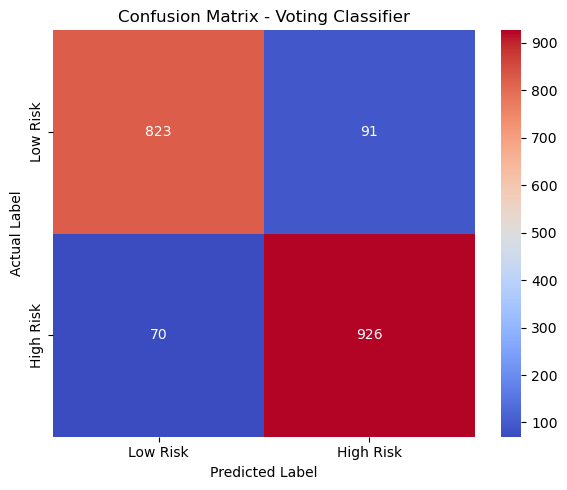

In [27]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_vote)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Voting Classifier")

plt.tight_layout()
plt.show()

- The confusion matrix summarizes the performance of the Voting Classifier by comparing actual and predicted patient risk categories. The model correctly identified most high-risk patients while producing only a small number of False Negatives. Since missing a high-risk patient can delay medical intervention, achieving a low False Negative count is particularly important. Although a few False Positives may occur, they are generally preferable in healthcare screening because they allow additional medical evaluation rather than overlooking patients who may require treatment.

## Results

| Model | Recall |
|----------------------|:------:|
| Logistic Regression | 82.8% |
| K-Nearest Neighbors (KNN) | 88.3% |
| Random Forest | **95.8%** |
| Gradient Boosting | 94.9% |
| Voting Classifier | 93.07% |

### Model Selection

Among all the evaluated models, **Random Forest** achieved the highest **Recall (95.8%)** while maintaining an **Accuracy of 93.7%**. Since the primary objective of this project is to minimize **False Negatives** and correctly identify high-risk patients, **Random Forest** was selected as the final model for patient risk prediction.

Its high recall makes it well suited for healthcare screening applications, where identifying patients at risk is more critical than minimizing false alarms. By reducing missed high-risk cases, the model can support earlier clinical intervention and improve patient care outcomes.